# FIG8: Forward-dynamics accuracy of ANNet with noisy gravitational torques

This notebook regenerates manuscript Figure 8 from the packaged data archive `FIG8.zip` or `FIG8`.
The archive must be in the same folder as this notebook. Every plotted value is read from the archive, and the notebook asserts that no value falls outside the axes, then saves `FIG8.svg`, `FIG8.pdf` and `FIG8.png`.

Saved FIG8.svg


Saved FIG8.pdf


Saved FIG8.png


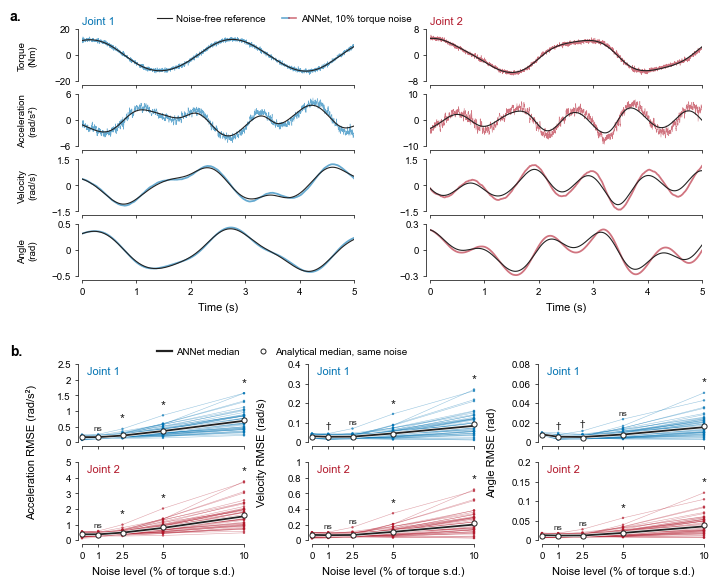

Panel b: 1500 ANNet values drawn (50 trajectories per noise level, quantity and joint); analytical medians from 1500 values.
Example trajectory (panel a): index 44 of the 50 trajectories at 10% noise, 2500 time points; trajectory whose errors with the learned energy at this noise level lie closest to the medians of the six combinations of quantity and joint: smallest sum of |log(error / median error)|.
Noise model:
  zero-mean Gaussian, independent across the two joints and across solver steps; perturbed input = gravitational torque G(q) of the current simulated state, at every solver step
  standard deviation = noise level times the standard deviation of the gravitational torque of that joint over the noise-free reference trajectory (unbiased estimate over the 2,500 steps)
  levels (%) = [1.0, 2.5, 5.0, 10.0], seed = 37; initial conditions: exact initial angles and velocities of the reference trajectories (not perturbed)
Median RMSE of ANNet / of the analytical energy on the same nois

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIG8.zip or FIG8 must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIG8.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIG8")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIG8.zip or FIG8 in the current folder. "
        "Place the data archive in the same folder as FIG8.ipynb."
    )

if DATA_ARCHIVE.is_dir():
    def open_member(name):
        return open(DATA_ARCHIVE / name, "rb")
else:
    _archive = zipfile.ZipFile(DATA_ARCHIVE)

    def open_member(name):
        return _archive.open(name)

# The tables are parsed with exact round-trip precision, so the values equal those the analysis notebook plotted
rmse_table = pd.read_csv(open_member("fig8_rmse_values.csv"), float_precision="round_trip")
solver_stats_table = pd.read_csv(open_member("fig8_solver_statistics.csv"), float_precision="round_trip")
level_stats_table = pd.read_csv(open_member("fig8_level_statistics.csv"), float_precision="round_trip")
traces_table = pd.read_csv(open_member("fig8_example_traces.csv"), float_precision="round_trip")
metadata = json.load(open_member("fig8_metadata.json"))
figure_percent = float(metadata["figure"]["noise_percent_of_panel_a"])

import matplotlib.patheffects as pe
from matplotlib.legend_handler import HandlerTuple
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# Fig. 8 plotting code (the same drawing in MAIN_RUN_ME_NEW.ipynb and FIG8.ipynb).
# a: example trajectory at one noise level, joint 1 (blue) on the left and joint 2
#    (red) on the right. From top to bottom: the gravitational torque that entered
#    the solver and the acceleration, velocity and angle that the solver with the
#    learned energy returned (colour), each with the noise-free reference (dark line).
# b: trajectory-wise RMSE of acceleration, velocity and angle against the level of
#    noise on the gravitational torques, joint 1 above joint 2. Each thin line is one
#    trajectory of the solver with the learned energy, the heavy line joins its
#    medians and open circles are the medians of the solver with the analytical
#    energy under the same noise. An asterisk marks a noise level whose errors are
#    higher than the noise-free errors and a dagger one whose errors are lower (both
#    FDR q < 0.05); 'ns' marks a level whose errors do not differ.
# No value is removed, and the axes are asserted to enclose every plotted value.
# -----------------------------------------------------------------------------
FIG8_BLUE = '#0072B2'
FIG8_RED = '#B2182B'
FIG8_NEUTRAL = '#222222'
FIG8_JOINTS = ['J1', 'J2']
FIG8_JOINT_COLORS = {'J1': FIG8_BLUE, 'J2': FIG8_RED}
# Rows of panel a: column suffix in the traces table, axis label
FIG8_TRACE_ROWS = [('g', 'Torque\n(Nm)'), ('ddq', 'Acceleration\n(rad/s\u00b2)'), ('dq', 'Velocity\n(rad/s)'), ('q', 'Angle\n(rad)')]
# Columns of panel b: quantity in the RMSE table, axis label
FIG8_QUANTITIES = [('acceleration', 'Acceleration RMSE (rad/s\u00b2)'), ('velocity', 'Velocity RMSE (rad/s)'), ('angle', 'Angle RMSE (rad)')]
FIG8_RC = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.major.pad': 2.5,
    'ytick.major.pad': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    # Export at the canvas size irrespective of the kernel's global rcParams
    'savefig.bbox': 'standard',
    'figure.dpi': 100,
    'savefig.dpi': 600,
}


def fig8_symmetric_limit(largest):
    # Smallest symmetric axis limit of the form 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8 x 10^k that encloses the data
    for exponent in range(-4, 4):
        for mantissa in (1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0):
            if mantissa * 10.0 ** exponent >= largest:
                return mantissa * 10.0 ** exponent
    raise ValueError('value outside the supported range')


def fig8_axis_top(maximum):
    # Smallest axis end on a 1-2-5 x 10^k tick step that encloses the data with at most five intervals
    for exponent in range(-5, 4):
        for mantissa in (1.0, 2.0, 5.0):
            step = mantissa * 10.0 ** exponent
            intervals = int(np.ceil(maximum / step - 1e-9))
            if intervals <= 5:
                return intervals * step, step
    raise ValueError('value outside the supported range')


def fig8_number(value, _=None):
    return f"{value:,g}".replace('-', '−')


def draw_fig8(rmse_table, level_stats_table, traces_table, figure_percent):
    """
    rmse_table:        long-form table with columns model, noise_percent, quantity, joint, trajectory, rmse.
    level_stats_table: one row per model, quantity, joint and noise level with the columns significant_fdr_0_05
                       and direction (errors at that level against the noise-free errors of the same solver).
    traces_table:      one row per time point of the example trajectory with the columns time_s, reference_*_j*
                       and, per solver and noise level, <solver>_<level>pct_<g, q, dq, ddq>_j*.
    figure_percent:    noise level (%) of the example trajectory of panel a.
    Returns the matplotlib figure (two panels, double-column width).
    """
    levels = np.asarray(sorted(float(percent) for percent in rmse_table['noise_percent'].unique()))
    assert levels[0] == 0.0 and figure_percent in levels

    def select(model_name, quantity, joint, percent):
        mask = ((rmse_table['model'] == model_name) & (rmse_table['quantity'] == quantity)
                & (rmse_table['joint'] == joint) & (rmse_table['noise_percent'] == percent))
        return rmse_table.loc[mask].sort_values('trajectory')['rmse'].to_numpy(dtype=float)

    # ---- geometry in inches, measured from the left and from the top of the canvas ----
    width, height = 7.2, 6.05
    fig = plt.figure(figsize=(width, height))

    def add_axes(left, top, span, tall):
        ax = fig.add_axes([left / width, 1.0 - (top + tall) / height, span / width, tall / height])
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
        ax.yaxis.set_major_formatter(FuncFormatter(fig8_number))
        ax.xaxis.set_major_formatter(FuncFormatter(fig8_number))
        return ax

    median_style = dict(color=FIG8_NEUTRAL, lw=1.3, solid_capstyle='butt',
                        path_effects=[pe.withStroke(linewidth=2.3, foreground='white')])
    circle_style = dict(facecolors='white', edgecolors=FIG8_NEUTRAL, linewidths=0.7)

    # ---- a: example trajectory, joint 1 on the left and joint 2 on the right ----
    time = traces_table['time_s'].to_numpy(dtype=float)
    a_top, a_row, a_gap = 0.42, 0.52, 0.13
    a_left = {'J1': 0.80, 'J2': 4.28}
    a_span = 2.72
    trace_axes = {}
    for joint in FIG8_JOINTS:
        color = FIG8_JOINT_COLORS[joint]
        for row, (name, label) in enumerate(FIG8_TRACE_ROWS):
            ax = add_axes(a_left[joint], a_top + row * (a_row + a_gap), a_span, a_row)
            trace_axes[(joint, name)] = ax
            # The traces are stored in single precision
            reference = traces_table[f"reference_{name}_{joint.lower()}"].to_numpy(dtype=np.float32).astype(float)
            noisy = traces_table[f"annet_{figure_percent:g}pct_{name}_{joint.lower()}"].to_numpy(dtype=np.float32).astype(float)
            ax.plot(time, noisy, color=color, lw=0.35 if name in ('g', 'ddq') else 1.3, alpha=0.6, zorder=2,
                    rasterized=name in ('g', 'ddq'))
            ax.plot(time, reference, color=FIG8_NEUTRAL, lw=0.8, zorder=3)
            limit = fig8_symmetric_limit(max(np.abs(noisy).max(), np.abs(reference).max()))
            assert max(np.abs(noisy).max(), np.abs(reference).max()) <= limit
            ax.set_xlim(time[0], 5.0)
            ax.set_ylim(-limit, limit)
            ax.set_xticks(np.arange(0.0, 5.5, 1.0))
            ax.set_yticks([-limit, 0, limit])
            if row < len(FIG8_TRACE_ROWS) - 1:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel('Time (s)')
            if joint == 'J1':
                ax.set_ylabel(label, fontsize=7, labelpad=3)
                ax.yaxis.set_label_coords(-0.165, 0.5)
        trace_axes[(joint, 'g')].text(0.0, 1.06, f"Joint {joint[1]}", transform=trace_axes[(joint, 'g')].transAxes, ha='left',
                                     va='bottom', fontsize=8, color=color)
    fig.legend(handles=[Line2D([0], [0], color=FIG8_NEUTRAL, lw=0.8),
                        (Line2D([0], [0], color=FIG8_BLUE, lw=1.2, alpha=0.6), Line2D([0], [0], color=FIG8_RED, lw=1.2, alpha=0.6))],
               labels=['Noise-free reference', f"ANNet, {figure_percent:g}% torque noise"],
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0.0)}, loc='lower left',
               bbox_to_anchor=((a_left['J1'] + 0.75) / width, 1.0 - (a_top - 0.06) / height), ncol=2, frameon=False,
               handlelength=1.5, handletextpad=0.5, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- b: errors against the noise level, quantities in columns, joint 1 above joint 2 ----
    b_top = a_top + 4 * a_row + 3 * a_gap + 0.88
    b_row, b_gap = 0.78, 0.2
    b_left = [0.80, 3.10, 5.40]
    b_span = 1.62
    fan_axes = {}
    marks = []
    for column, (quantity, label) in enumerate(FIG8_QUANTITIES):
        for row, joint in enumerate(FIG8_JOINTS):
            color = FIG8_JOINT_COLORS[joint]
            ax = add_axes(b_left[column], b_top + row * (b_row + b_gap), b_span, b_row)
            fan_axes[(quantity, joint)] = ax
            annet = np.stack([select('ANNet', quantity, joint, percent) for percent in levels])
            analytical = np.asarray([np.median(select('analytical', quantity, joint, percent)) for percent in levels])
            # Head room above the data for the significance marks
            y_top, y_step = fig8_axis_top(1.3 * annet.max())
            assert (annet >= 0.0).all() and (annet <= y_top).all() and (analytical <= y_top).all()
            for i in range(annet.shape[1]):
                ax.plot(levels, annet[:, i], color=color, lw=0.4, alpha=0.4, zorder=2, clip_on=False)
            ax.scatter(np.repeat(levels, annet.shape[1]), annet.ravel(), color=color, s=3, edgecolors='none', alpha=0.7,
                       zorder=3, clip_on=False)
            ax.plot(levels, np.median(annet, axis=1), zorder=5, clip_on=False, **median_style)
            ax.scatter(levels, analytical, s=14, zorder=7, clip_on=False, **circle_style)
            # Difference from the noise-free errors after FDR correction: asterisk if higher, dagger if lower, 'ns' otherwise
            for k, percent in enumerate(levels[1:], start=1):
                stats_row = level_stats_table[(level_stats_table['model'] == 'ANNet') & (level_stats_table['quantity'] == quantity)
                                              & (level_stats_table['joint'] == joint) & (level_stats_table['noise_percent'] == percent)]
                assert len(stats_row) == 1
                significant = bool(stats_row['significant_fdr_0_05'].iloc[0])
                lower = str(stats_row['direction'].iloc[0]) == 'lower'
                mark = ('\u2020' if lower else '*') if significant else 'ns'
                marks.append((ax, annet[k], ax.text(percent, annet[k].max() + 0.04 * y_top, mark, ha='center', va='bottom',
                                                    fontsize={'*': 9, '\u2020': 7, 'ns': 6}[mark], color=FIG8_NEUTRAL)))
            ax.set_xlim(0.0, levels[-1])
            ax.set_ylim(0.0, y_top)
            ax.set_xticks(levels)
            ax.set_yticks(np.arange(0.0, y_top + 0.5 * y_step, y_step))
            if row == 0:
                ax.tick_params(labelbottom=False)
            else:
                ax.set_xlabel('Noise level (% of torque s.d.)')
            ax.text(0.03, 0.97, f"Joint {joint[1]}", transform=ax.transAxes, ha='left', va='top', fontsize=8, color=color)
        fig.text((b_left[column] - 0.50) / width, 1.0 - (b_top + b_row + 0.5 * b_gap) / height, label, rotation=90,
                 ha='center', va='center', fontsize=8)
    fig.legend(handles=[Line2D([0], [0], color=FIG8_NEUTRAL, lw=1.6),
                        Line2D([0], [0], marker='o', linestyle='None', markersize=3.6, markerfacecolor='white',
                               markeredgecolor=FIG8_NEUTRAL, markeredgewidth=0.7)],
               labels=['ANNet median', 'Analytical median, same noise'], loc='lower left',
               bbox_to_anchor=((b_left[0] + 0.75) / width, 1.0 - (b_top - 0.08) / height), ncol=2, frameon=False,
               handlelength=1.5, handletextpad=0.5, columnspacing=1.6, borderaxespad=0.0, borderpad=0.0)

    # ---- panel labels ----
    for letter, top in (('a.', a_top), ('b.', b_top)):
        fig.text(0.08 / width, 1.0 - (top - 0.06) / height, letter, fontsize=10, fontweight='bold', ha='left', va='bottom')

    # The significance marks must stay inside the axes
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, values, mark in marks:
        box = mark.get_window_extent(renderer).transformed(ax.transData.inverted())
        assert box.y1 <= ax.get_ylim()[1], 'a significance mark of panel b leaves the axes'
        assert box.y0 >= values.max(), 'a significance mark of panel b meets the data'
    return fig

mpl.rcParams.update(FIG8_RC)
fig = draw_fig8(rmse_table, level_stats_table, traces_table, figure_percent)
for ext in ("svg", "pdf", "png"):
    path = Path(f"FIG8.{ext}")
    fig.savefig(path, facecolor="white")
    print(f"Saved {path}")
plt.show()

# Every archived value of the solver with the learned energy is drawn once in panel b;
# the open circles are medians of all archived values of the solver with the analytical energy
_levels = sorted(rmse_table["noise_percent"].unique())
_drawn = rmse_table[rmse_table["model"] == "ANNet"]
_reference = rmse_table[rmse_table["model"] == "analytical"]
assert len(_drawn) == 300 * len(_levels) and _drawn.groupby(["noise_percent", "quantity", "joint"]).trajectory.nunique().eq(50).all()
assert len(_reference) == 300 * len(_levels) and _reference.groupby(["noise_percent", "quantity", "joint"]).trajectory.nunique().eq(50).all()
print(f"Panel b: {len(_drawn)} ANNet values drawn (50 trajectories per noise level, quantity and joint); "
      f"analytical medians from {len(_reference)} values.")
print(f"Example trajectory (panel a): index {metadata['example_trajectory']['index']} of the 50 trajectories at {figure_percent:g}% noise, "
      f"{len(traces_table)} time points; {metadata['example_trajectory']['selection_rule']}.")
print("Noise model:")
print(f"  {metadata['noise_model']['distribution']}; perturbed input = {metadata['noise_model']['perturbed_input']}")
print(f"  standard deviation = {metadata['noise_model']['standard_deviation']}")
print(f"  levels (%) = {metadata['noise_model']['noise_levels_percent']}, seed = {metadata['noise_model']['seed']}; "
      f"initial conditions: {metadata['noise_model']['initial_conditions']}")
print("Median RMSE of ANNet / of the analytical energy on the same noisy torques:")
_medians = rmse_table.groupby(["quantity", "unit", "joint", "noise_percent", "model"]).rmse.median().unstack("model")
print(_medians[["ANNet", "analytical"]].to_string())
print(f"ANNet against the analytical energy (primary test, FDR-adjusted across {len(solver_stats_table)} comparisons; "
      f"{int(solver_stats_table['significant_fdr_0_05'].sum())} significant):")
print(solver_stats_table[["quantity", "joint_label", "noise_percent", "test_name", "p_value", "fdr_q_value", "significant_fdr_0_05",
                          "median_ratio_annet_over_analytical", "wilcoxon_paired_p_two_sided", "n_annet_higher"]].to_string(index=False))
_annet_levels = level_stats_table[level_stats_table["model"] == "ANNet"]
print(f"ANNet, each noise level against no noise (primary test, FDR-adjusted across {len(_annet_levels)} comparisons; "
      f"{int(_annet_levels['significant_fdr_0_05'].sum())} significant):")
print(_annet_levels[["quantity", "joint_label", "noise_percent", "test_name", "p_value", "fdr_q_value", "significant_fdr_0_05",
                     "median_noise_free", "median_noisy", "median_ratio_noisy_over_noise_free", "median_added_by_noise_per_percent",
                     "wilcoxon_paired_p_two_sided", "n_higher_than_noise_free"]].to_string(index=False))
